In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
hospital_data = pd.read_csv("hospital_appointment.csv")

In [3]:
hospital_data

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589980e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262960e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679510e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841190e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110522,2.572130e+12,5651768,F,2016-05-03T09:15:35Z,2016-06-07T00:00:00Z,56,MARIA ORTIZ,0,0,0,0,0,1,No
110523,3.596270e+12,5650093,F,2016-05-03T07:27:33Z,2016-06-07T00:00:00Z,51,MARIA ORTIZ,0,0,0,0,0,1,No
110524,1.557660e+13,5630692,F,2016-04-27T16:03:52Z,2016-06-07T00:00:00Z,21,MARIA ORTIZ,0,0,0,0,0,1,No
110525,9.213490e+13,5630323,F,2016-04-27T15:09:23Z,2016-06-07T00:00:00Z,38,MARIA ORTIZ,0,0,0,0,0,1,No


In [4]:
hospital_data.tail()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
110522,2.572130e+12,5651768,F,2016-05-03T09:15:35Z,2016-06-07T00:00:00Z,56,MARIA ORTIZ,0,0,0,0,0,1,No
110523,3.596270e+12,5650093,F,2016-05-03T07:27:33Z,2016-06-07T00:00:00Z,51,MARIA ORTIZ,0,0,0,0,0,1,No
110524,1.557660e+13,5630692,F,2016-04-27T16:03:52Z,2016-06-07T00:00:00Z,21,MARIA ORTIZ,0,0,0,0,0,1,No
110525,9.213490e+13,5630323,F,2016-04-27T15:09:23Z,2016-06-07T00:00:00Z,38,MARIA ORTIZ,0,0,0,0,0,1,No
110526,3.775120e+14,5629448,F,2016-04-27T13:30:56Z,2016-06-07T00:00:00Z,54,MARIA ORTIZ,0,0,0,0,0,1,No


In [5]:
hospital_data.shape

(110527, 14)

In [6]:
hospital_data.columns

Index(['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay',
       'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hipertension',
       'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'No-show'],
      dtype='str')

In [7]:
hospital_data.rename(columns={'No-show': 'No_show'}, inplace=True)
hospital_data.rename(columns={'Hipertension': 'Hypertension'}, inplace=True)
hospital_data.rename(columns={'Handcap': 'Handicap'}, inplace=True)

In [8]:
hospital_data.info()


<class 'pandas.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  str    
 3   ScheduledDay    110527 non-null  str    
 4   AppointmentDay  110527 non-null  str    
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  str    
 7   Scholarship     110527 non-null  int64  
 8   Hypertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handicap        110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No_show         110527 non-null  str    
dtypes: float64(1), int64(8), str(5)
memory usage: 17.6 MB


In [9]:
hospital_data.describe()

,PatientId,AppointmentID,Age,Scholarship,Hypertension,Diabetes,Alcoholism,Handicap,SMS_received
count,1.105270e+05,1.105270e+05,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,1.474963e+14,5.675305e+06,37.088874,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026
std,2.560949e+14,7.129575e+04,23.110205,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873
min,3.920000e+04,5.030230e+06,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.172615e+12,5.640286e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173180e+13,5.680573e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.439170e+13,5.725524e+06,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,9.999820e+14,5.790484e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000


In [10]:
hospital_data.isnull().sum()

PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
Scholarship       0
Hypertension      0
Diabetes          0
Alcoholism        0
Handicap          0
SMS_received      0
No_show           0
dtype: int64

In [11]:
hospital_data.nunique()

PatientId          61744
AppointmentID     110527
Gender                 2
ScheduledDay      103549
AppointmentDay        27
Age                  104
Neighbourhood         81
Scholarship            2
Hypertension           2
Diabetes               2
Alcoholism             2
Handicap               5
SMS_received           2
No_show                2
dtype: int64

In [12]:
hospital_data1 = hospital_data[['Gender','Scholarship', 'Hypertension','Diabetes', 'Alcoholism', 'Handicap',
                                'SMS_received', 'No_show']]

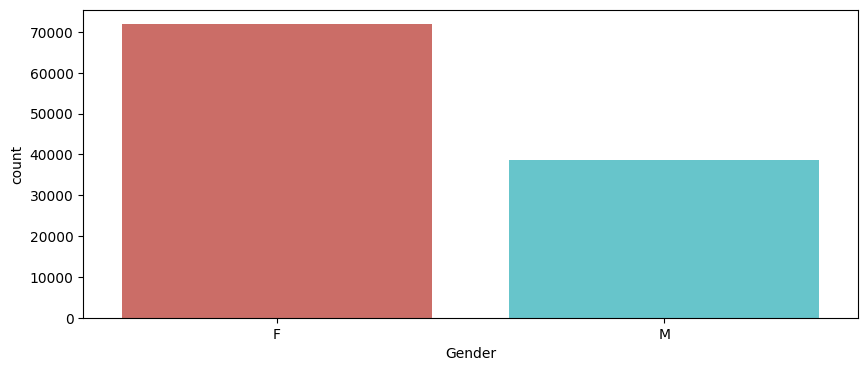

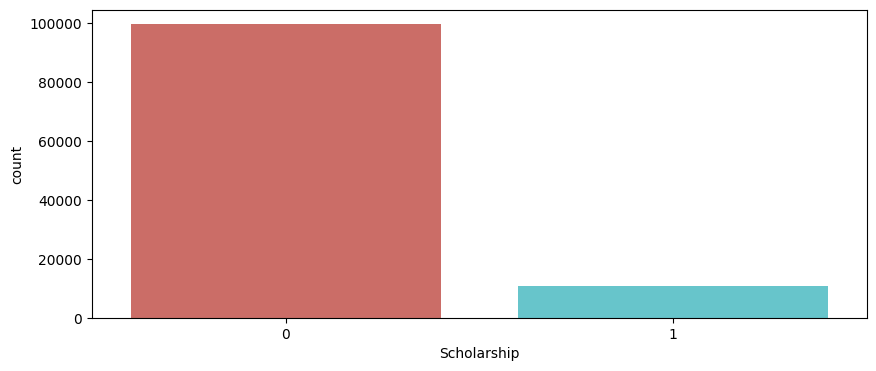

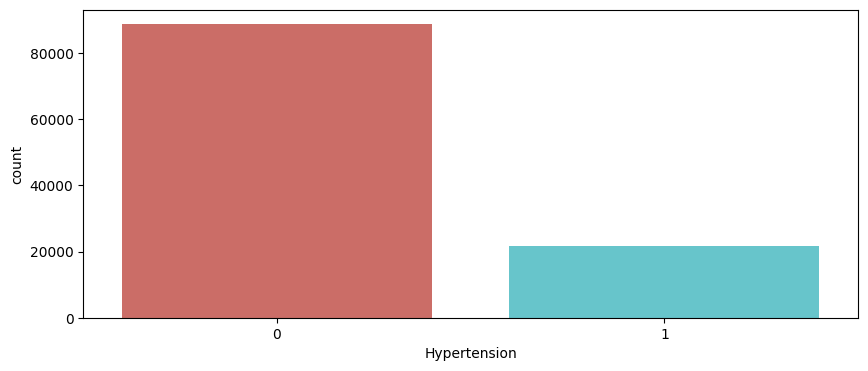

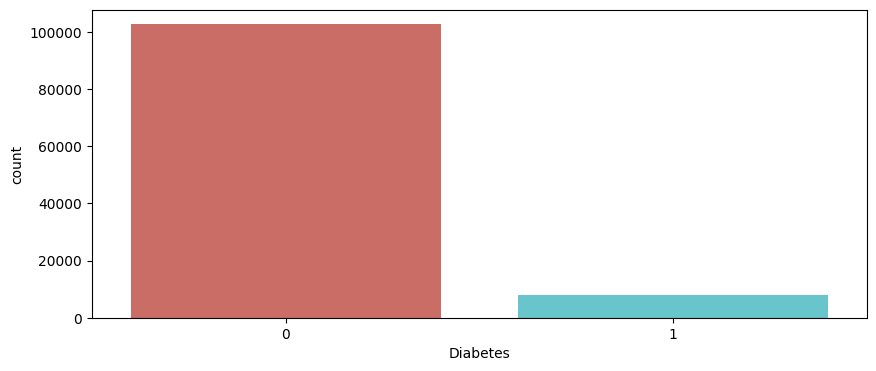

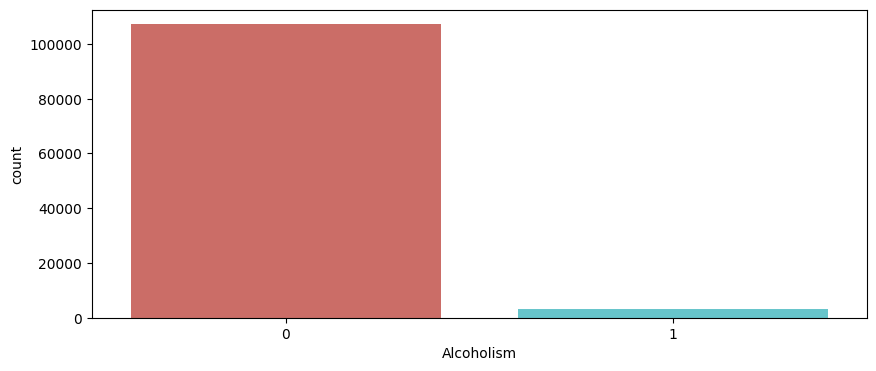

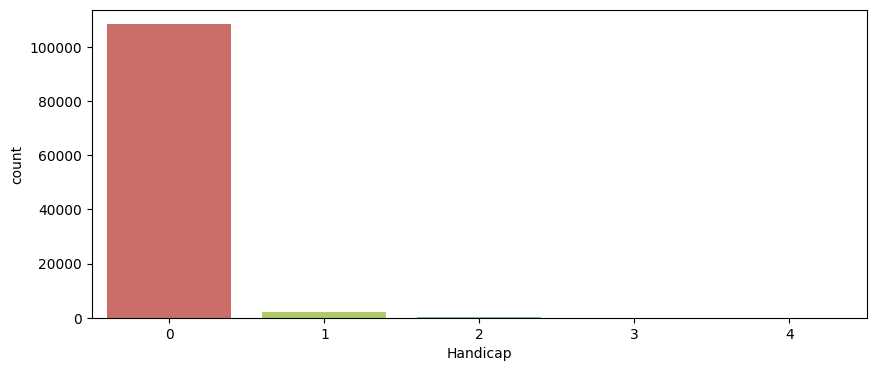

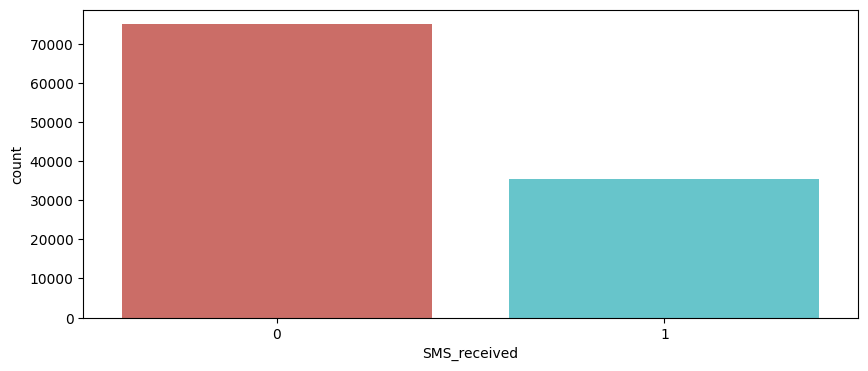

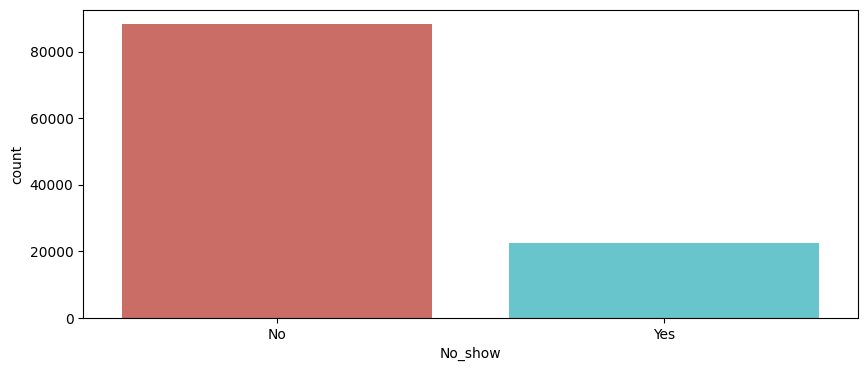

In [13]:
for i in hospital_data1.columns:
    plt.figure(figsize=(10, 4))
    sns.countplot(x=i, data=hospital_data1, palette='hls')
    plt.show()

In [14]:
hospital_data2 = hospital_data.copy()

In [15]:
hospital_data2.drop(['PatientId','AppointmentID','ScheduledDay','AppointmentDay'], axis=1)

,Gender,Age,Neighbourhood,Scholarship,Hypertension,Diabetes,Alcoholism,Handicap,SMS_received,No_show
0,F,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,M,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,F,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,F,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,F,56,JARDIM DA PENHA,0,1,1,0,0,0,No
...,...,...,...,...,...,...,...,...,...,...
110522,F,56,MARIA ORTIZ,0,0,0,0,0,1,No
110523,F,51,MARIA ORTIZ,0,0,0,0,0,1,No
110524,F,21,MARIA ORTIZ,0,0,0,0,0,1,No
110525,F,38,MARIA ORTIZ,0,0,0,0,0,1,No


In [16]:
hospital_data2['Age'].replace(0, hospital_data2['Age'].mean() , inplace = True)

0         62.0
1         56.0
2         62.0
3          8.0
4         56.0
          ... 
110522    56.0
110523    51.0
110524    21.0
110525    38.0
110526    54.0
Name: Age, Length: 110527, dtype: float64

In [17]:
hospital_data2['Age'] = hospital_data2['Age'].abs()

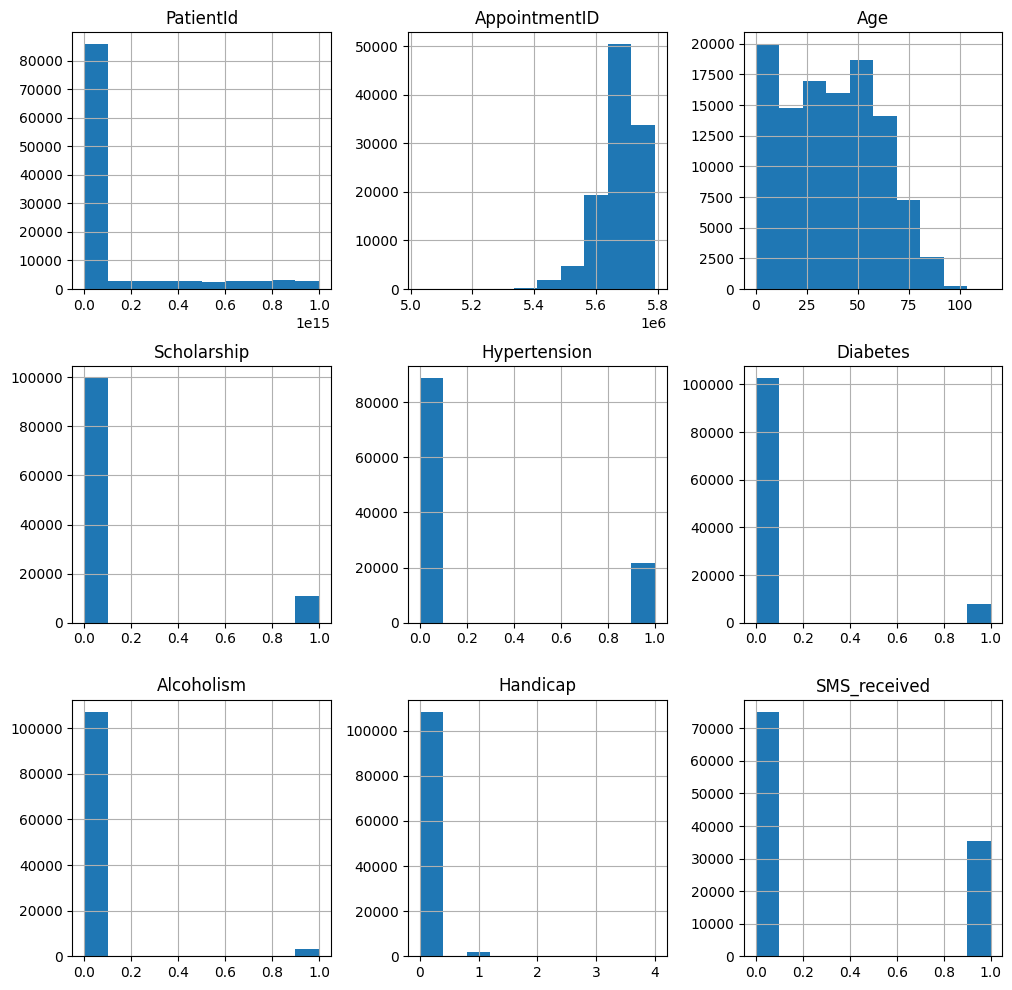

In [18]:
hospital_data2.hist(figsize=(12,12));

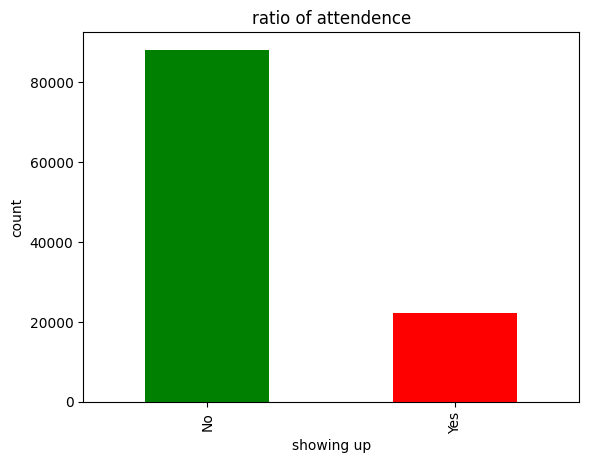

In [19]:
hospital_data2.No_show.value_counts().plot.bar(color=['green','red']);
plt.title("ratio of attendence")
plt.xlabel("showing up")
plt.ylabel("count")
plt.show()

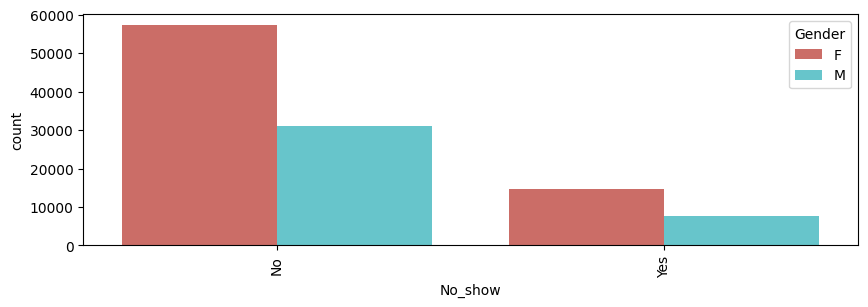

In [20]:
plt.figure(figsize=(10,3))
sns.countplot(x='No_show', hue='Gender', data=hospital_data2, palette='hls')
plt.xticks(rotation=90)
plt.show()

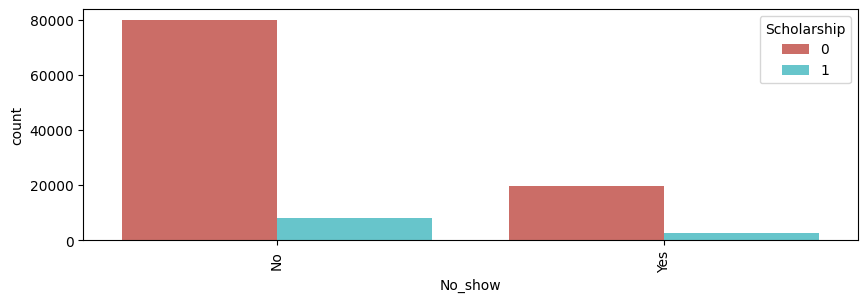

In [21]:
plt.figure(figsize=(10,3))
sns.countplot(x='No_show', hue='Scholarship', data=hospital_data2, palette='hls')
plt.xticks(rotation=90)
plt.show()

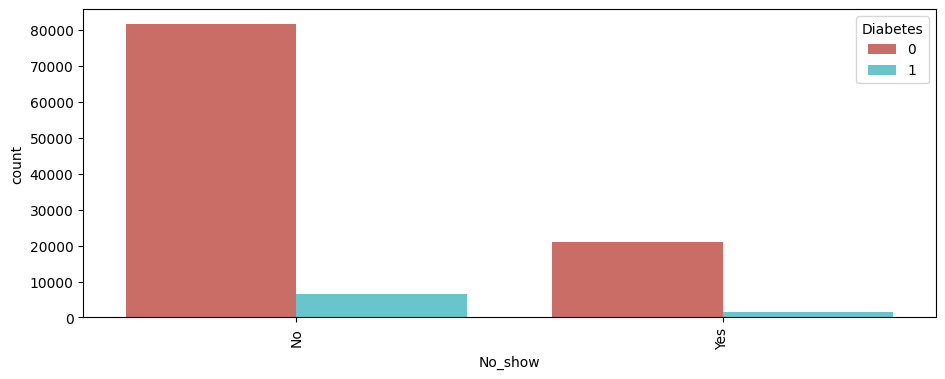

In [22]:
plt.figure(figsize=(11,4))
sns.countplot(x='No_show', hue='Diabetes', data=hospital_data2, palette='hls')
plt.xticks(rotation=90)
plt.show()

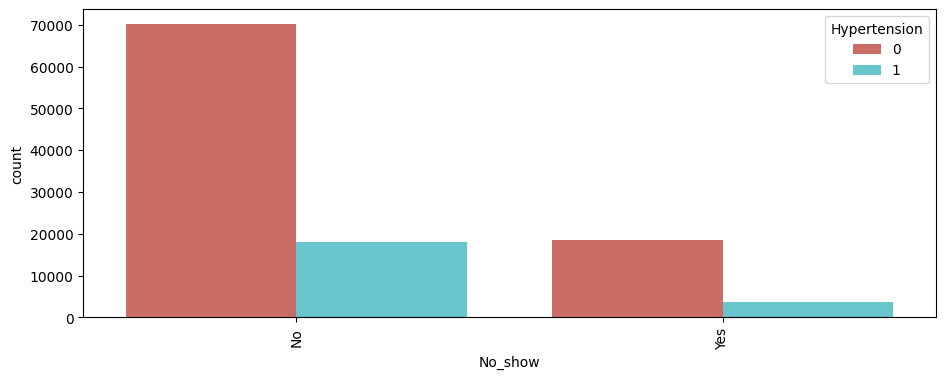

In [23]:
plt.figure(figsize=(11,4))
sns.countplot(x='No_show', hue='Hypertension', data=hospital_data2, palette='hls')
plt.xticks(rotation=90)
plt.show()

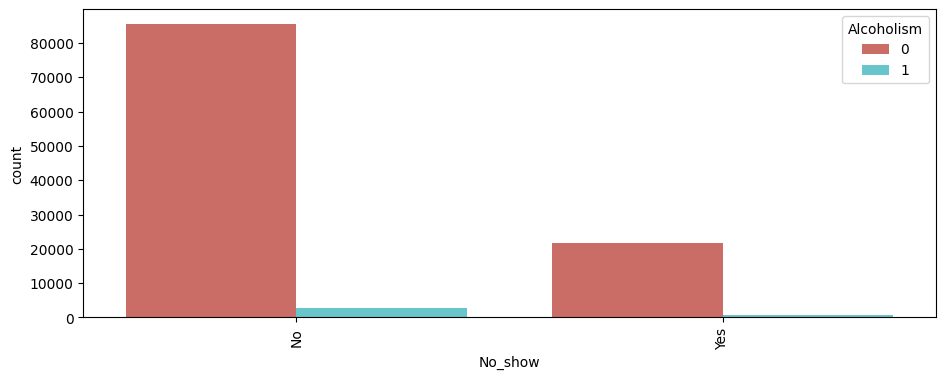

In [24]:
plt.figure(figsize=(11,4))
sns.countplot(x='No_show', hue='Alcoholism', data=hospital_data2, palette='hls')
plt.xticks(rotation=90)
plt.show()

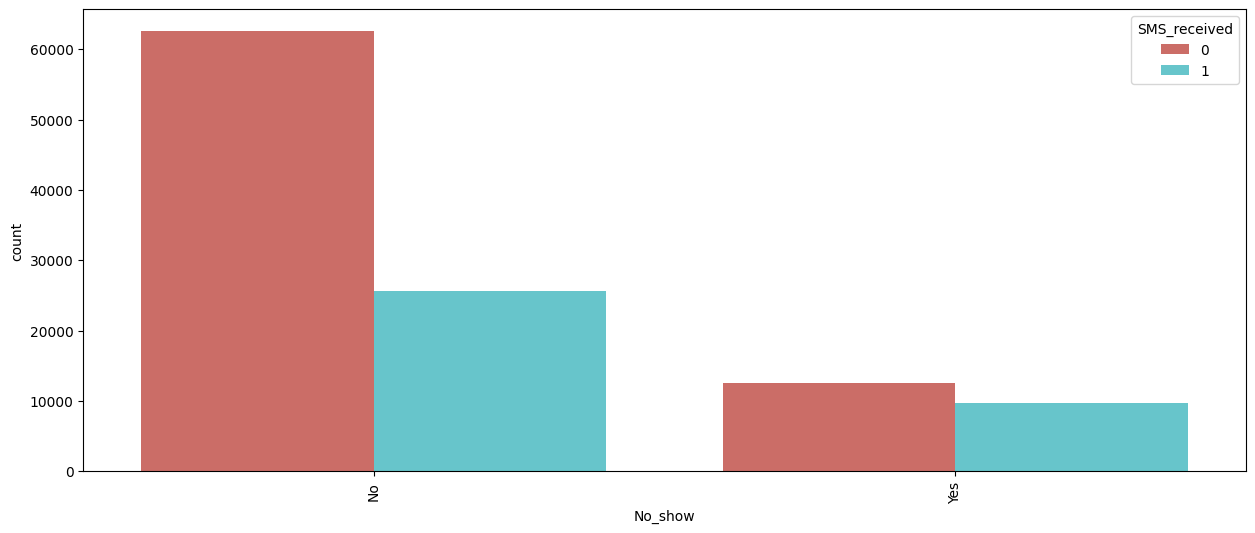

In [25]:
plt.figure(figsize=(15,6))
sns.countplot(x='No_show', hue='SMS_received', data=hospital_data2, palette='hls')
plt.xticks(rotation=90)
plt.show()

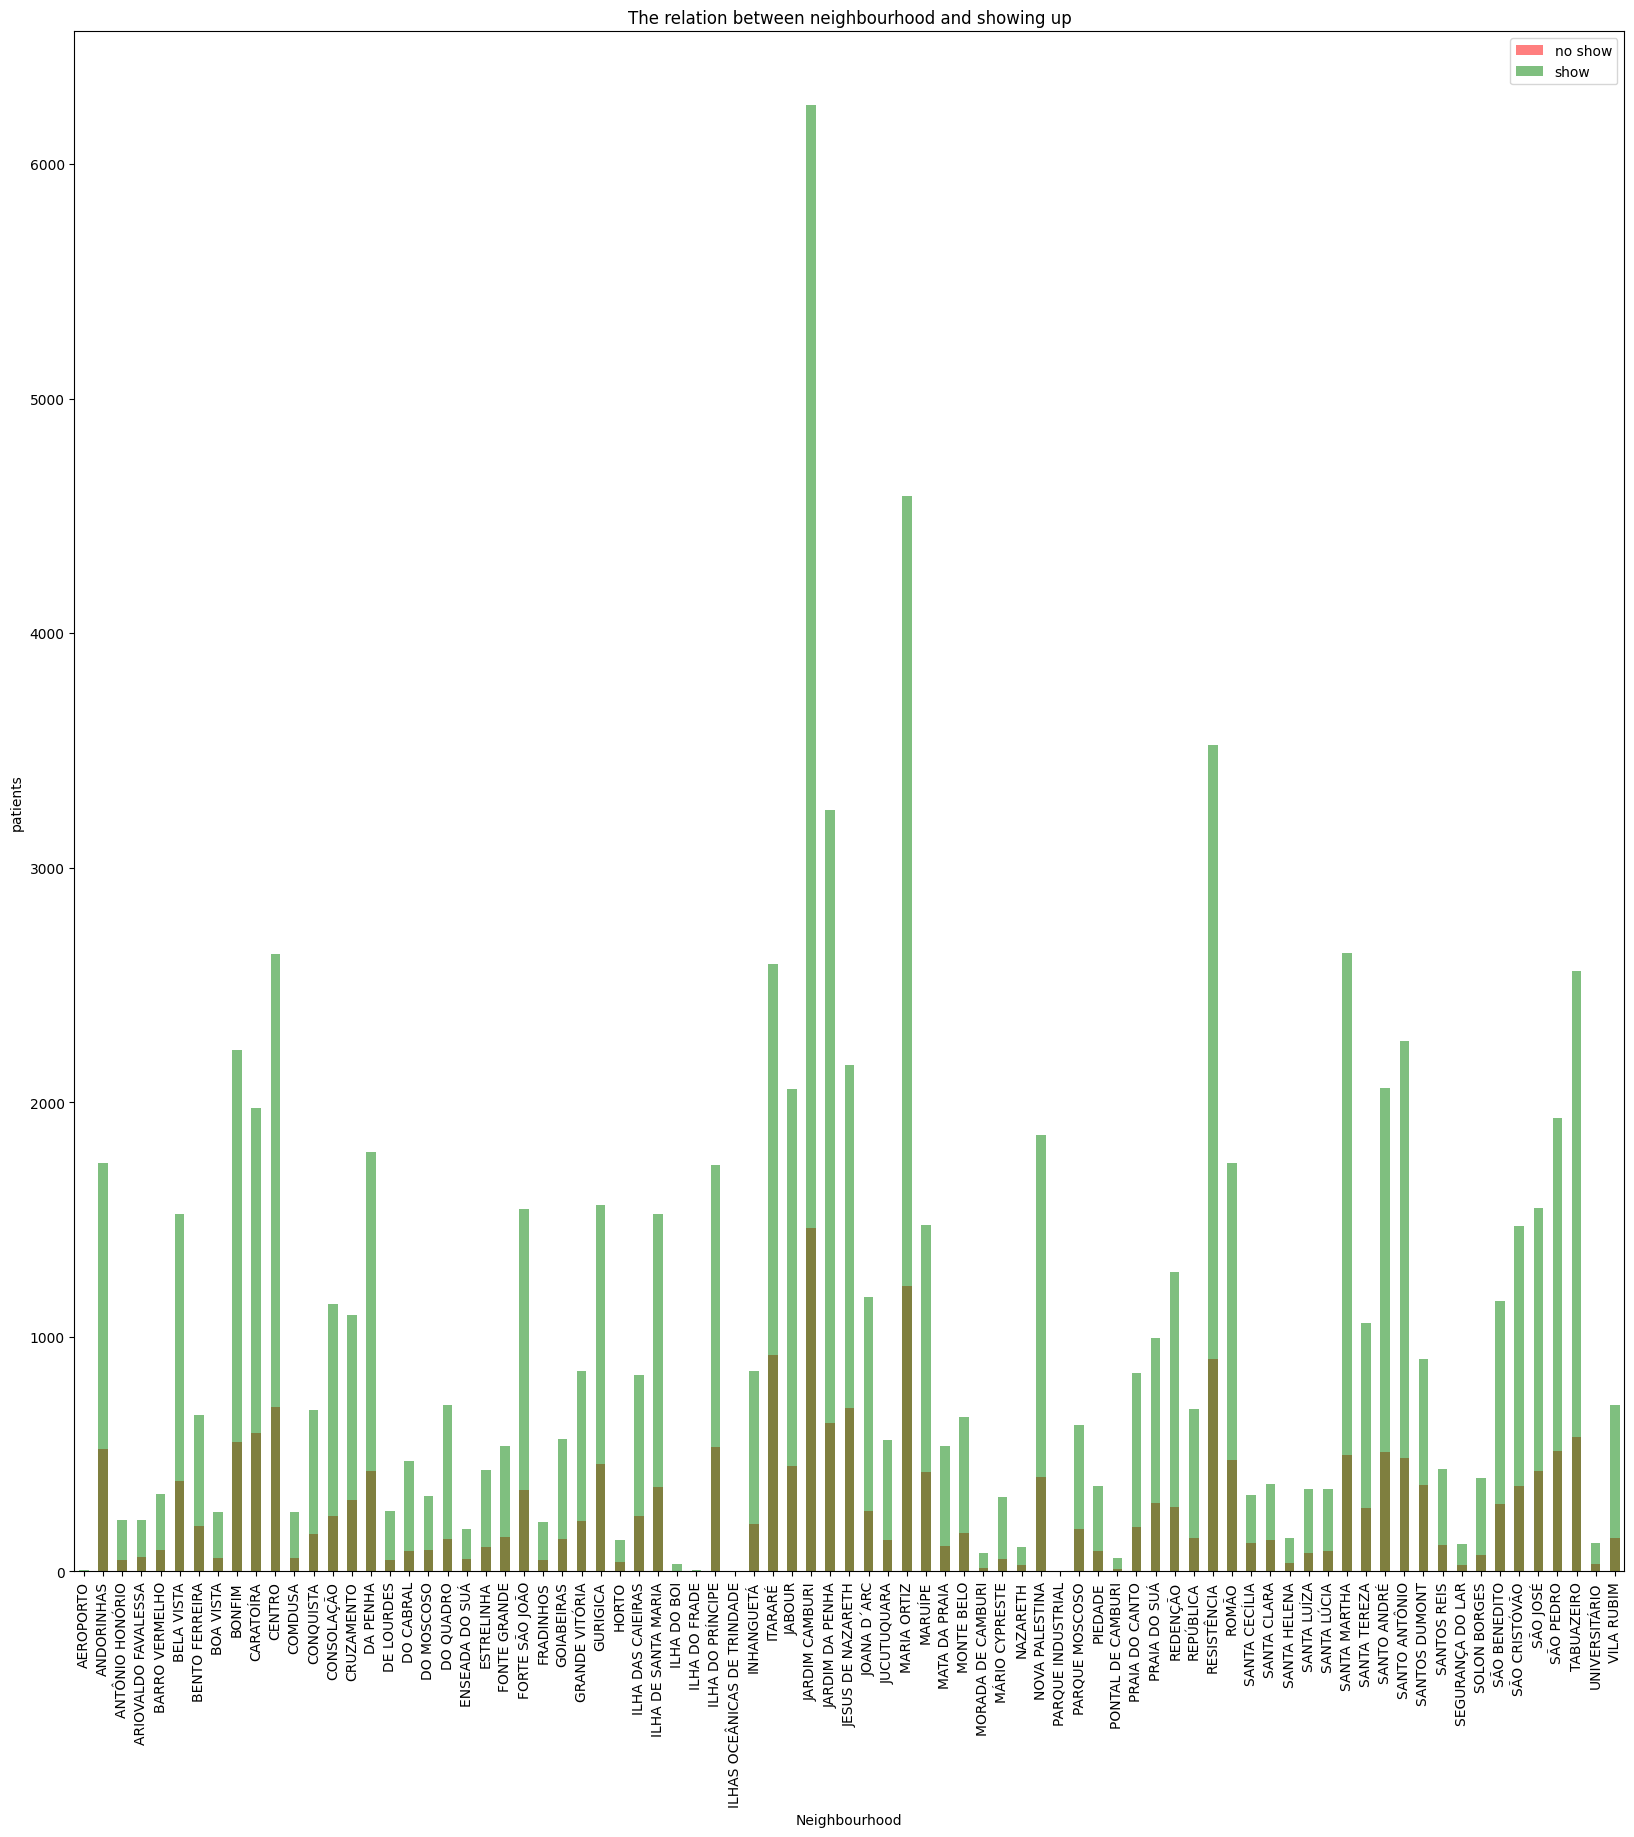

In [26]:
plt.figure(figsize=[20,20])
e = hospital_data2.groupby(['Neighbourhood','No_show']).size().unstack()
e.Yes.plot(kind='bar' , alpha=.5 , color = 'red' , label= 'no show')
e.No.plot(kind='bar' , alpha=.5 , color = 'green' , label= 'show')
plt.legend()
plt.title("The relation between neighbourhood and showing up")
plt.xlabel("Neighbourhood")
plt.ylabel("patients")
plt.show()

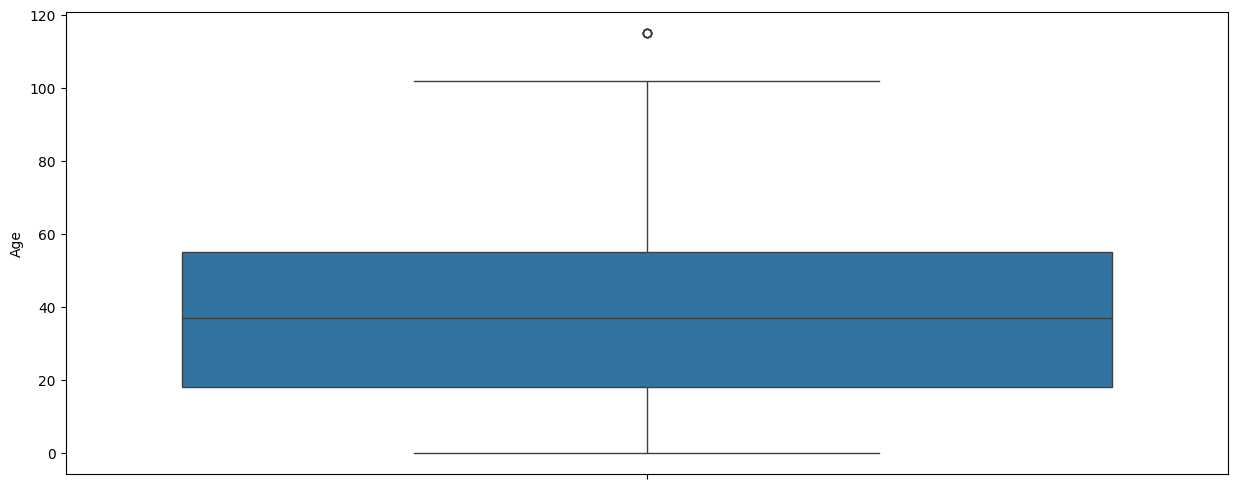

In [27]:
plt.figure(figsize=(15,6))
sns.boxplot(hospital_data2['Age'])
plt.show()

In [28]:
hospital_age= hospital_data2['Age']
Q3 = hospital_age.quantile(0.75)
Q1 = hospital_age.quantile(0.25)
IQR = Q3-Q1
lower_limit = Q1 -(1.5*IQR)
upper_limit = Q3 +(1.5*IQR)
age_outliers = hospital_age[(hospital_age <lower_limit) | (hospital_age >upper_limit)]
age_outliers

63912    115
63915    115
68127    115
76284    115
97666    115
Name: Age, dtype: int64

In [29]:
lower_limit

np.float64(-37.5)

In [30]:
upper_limit

np.float64(110.5)

In [31]:
hospital_data_new = hospital_data.drop([63912, 63915, 68127, 76284, 97666])


In [32]:
hospital_data_new.corr(numeric_only=True)

,PatientId,AppointmentID,Age,Scholarship,Hypertension,Diabetes,Alcoholism,Handicap,SMS_received
PatientId,1.000000,0.004027,-0.004157,-0.002879,-0.006492,0.001607,0.011013,-0.007820,-0.009792
AppointmentID,0.004027,1.000000,-0.019152,0.022617,0.012742,0.022631,0.032946,0.014111,-0.256635
Age,-0.004157,-0.019152,1.000000,-0.092431,0.504727,0.292510,0.095863,0.077370,0.012686
Scholarship,-0.002879,0.022617,-0.092431,1.000000,-0.019729,-0.024898,0.035020,-0.008520,0.001190
Hypertension,-0.006492,0.012742,0.504727,-0.019729,1.000000,0.433096,0.087973,0.080249,-0.006306
Diabetes,0.001607,0.022631,0.292510,-0.024898,0.433096,1.000000,0.018471,0.057629,-0.014554
Alcoholism,0.011013,0.032946,0.095863,0.035020,0.087973,0.018471,1.000000,0.004689,-0.026150
Handicap,-0.007820,0.014111,0.077370,-0.008520,0.080249,0.057629,0.004689,1.000000,-0.024025
SMS_received,-0.009792,-0.256635,0.012686,0.001190,-0.006306,-0.014554,-0.026150,-0.024025,1.000000


In [33]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in hospital_data_new.select_dtypes(include='object').columns:
    hospital_data_new[col] = le.fit_transform(hospital_data_new[col])

In [34]:
hospital_data_new.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hypertension,Diabetes,Alcoholism,Handicap,SMS_received,No_show
0,2.987250e+13,5642903,0,27740,0,62,39,0,1,0,0,0,0,0
1,5.589980e+14,5642503,1,27502,0,56,39,0,0,0,0,0,0,0
2,4.262960e+12,5642549,0,27537,0,62,45,0,0,0,0,0,0,0
3,8.679510e+11,5642828,0,27707,0,8,54,0,0,0,0,0,0,0
4,8.841190e+12,5642494,0,27496,0,56,39,0,1,1,0,0,0,0


In [35]:
from sklearn import preprocessing
label_encoder = preprocessing.LabelEncoder()
hospital_data_new['Gender']= label_encoder.fit_transform(hospital_data_new['Gender'])
hospital_data_new['No_show']= label_encoder.fit_transform(hospital_data_new['No_show'])

In [36]:
hospital_data_new['No_show']

0         0
1         0
2         0
3         0
4         0
         ..
110522    0
110523    0
110524    0
110525    0
110526    0
Name: No_show, Length: 110522, dtype: int64

In [37]:
hospital_data_new.columns

Index(['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay',
       'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hypertension',
       'Diabetes', 'Alcoholism', 'Handicap', 'SMS_received', 'No_show'],
      dtype='str')

In [38]:
x = hospital_data_new[['Gender', 'Scholarship', 'Hypertension','Diabetes', 'Alcoholism', 'Handicap', 'SMS_received']]

In [39]:
y = hospital_data['No_show']


In [40]:
x.shape

(110522, 7)

In [41]:
y.shape

(110527,)

In [42]:
from sklearn.model_selection import train_test_split

# Ensure same length
x, y = x.align(y, join='inner', axis=0)

# Split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [43]:
from sklearn.linear_model import LogisticRegression

In [44]:
classifier= LogisticRegression(random_state=0)
classifier.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",0
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multic

In [45]:
print("Training Accuracy :", classifier.score(x_train, y_train))
print("Testing Accuracy :", classifier.score(x_test, y_test))

Training Accuracy : 0.7983645678998382
Testing Accuracy : 0.7969690115358516


In [46]:
from sklearn.tree import DecisionTreeClassifier

In [47]:
classifier_dt= DecisionTreeClassifier(criterion='entropy', random_state=0)
classifier_dt.fit(x_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [48]:
print("Training Accuracy :", classifier_dt.score(x_train, y_train))
print("Testing Accuracy :", classifier_dt.score(x_test, y_test))

Training Accuracy : 0.7986020787857538
Testing Accuracy : 0.7970594888034381


In [49]:

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
import pickle

df = pd.read_csv("hospital_appointment.csv")

target = "No-show"

# Encode target
df[target] = df[target].map({'No': 0, 'Yes': 1})

# Drop useless columns
df = df.drop(columns=["PatientId", "AppointmentID"], errors='ignore')

X = df.drop(columns=[target])
y = df[target]

# Handle categorical safely
cat_cols = X.select_dtypes(include=['object']).columns

for col in cat_cols:
    if X[col].nunique() < 10:
        X = pd.get_dummies(X, columns=[col])
    else:
        X = X.drop(columns=[col])

# Fix index mismatch (lightweight)
X = X.reset_index(drop=True)
y = y.reset_index(drop=True)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

# Save
with open("hospital_model.pkl", "wb") as f:
    pickle.dump({
        "model": model,
        "columns": X.columns
    }, f)

print("Done without memory error")

Done without memory error


In [50]:

  import streamlit as st
import pandas as pd
import pickle

# Load model
with open("hospital_model.pkl", "rb") as f:
    data = pickle.load(f)

model = data["model"]
columns = data["columns"]

st.title("Hospital Appointment Prediction")

# Inputs
age = st.number_input("Age", 0, 100)
hypertension = st.selectbox("Hypertension", [0, 1])
diabetes = st.selectbox("Diabetes", [0, 1])

# Create input
input_data = pd.DataFrame({
    "Age": [age],
    "Hypertension": [hypertension],
    "Diabetes": [diabetes]
})

# Match columns
input_data = input_data.reindex(columns=columns, fill_value=0)

# Predict
if st.button("Predict"):
    prediction = model.predict(input_data)[0]
    
    result = "Yes" if prediction == 1 else "No"
    
    st.success(f"No-show Prediction: {result}")

IndentationError: unexpected indent (236895541.py, line 1)

In [ ]:
pip install streamlit

In [ ]:
import os
print(os.getcwd())


In [ ]:
code = """
import streamlit as st

st.title("Hospital Prediction App")
st.write("Streamlit is working ")
"""

with open("app.py", "w") as f:
    f.write(code)

print("app.py created successfully")

In [ ]:
! streamlit run app.py